# Consideration of Future Consequences Analysis
## Alex Tran, PhD

This is a small project aimed at categorizing, predicting, and analyzing who thinks about the future.

Credit to Yam Peleg for the dataset source (but now he is banned?)\
https://www.kaggle.com/datasets/yamqwe/consideration-of-future-consequences/data \
DOI: 10.34740/kaggle/dsv/2762636

Questions:
- How machine learning can augment personality research?
    - Application of k-means, ANN, and DecisionTreeRegressor
- How it compares to thoughtful analysis?
    - Simple logistic regressions, common sense categorization and variable manipulation
- Can it ML substantially improve categorization based on CFC score over chance?
    - Statistical comparison of R-square based on ML models and chance
    
## What can be found here
Section 1:  Dataset cleaning (outliers, missing values, reverse-scoring items), validation (remove unconscientious responders), and basic visualization \

Section 2: Basic descriptive statistics (gender, age, scale mean), feature generation (age/gender categories, extreme scorers)\

Section 3: Applying machine learning algorithms (k-means, ANN, DecisionTreeRegressor)

# DATASET INFORMATION

The following items were rated on a likert scale where:\
1=extremely uncharacteristic\
2=somewhat uncharacteristic\
3=uncertain\
4=somewhat characteristic\
5=extremely characteristic\
(0=no answer chosen)\

Q1. I consider how things might be in the future, and try to influence those things with my day to day behavior.  
Q2. Often I engage in a particular behavior in order to achieve outcomes that may not result for many years.  
Q3. I only act to satisfy immediate concerns, figuring the future will take care of itself.  
Q4. My behavior is only influenced by the immediate (i.e., a matter of days or weeks) outcomes of my actions.  
Q5. My convenience is a big factor in the decisions I make or the actions I take.  
Q6. I am willing to sacrifice my immediate happiness or well-being in order to achieve future outcomes.  
Q7. I think it is important to take warnings about negative outcomes seriously even if the negative outcome will not occur for many years.  
Q8. I think it is more important to perform a behavior with important distant consequences than a behavior with less-important immediate consequences.  
Q9. I generally ignore warnings about possible future problems because I think the problems will be resolved before they reach crisis level.  
Q10. I think that sacrificing now is usually unnecessary since future outcomes can be dealt with at a later time.\
Q11. I only act to satisfy immediate concerns, figuring that I will take care of future problems that may occur at a later date.  
Q12. Since my day to day work has specific outcomes, it is more important to me than behavior that has distant outcomes.

On the next page the following three variables were entered:

**age.** entered as text (ages < 13 removed)\
**gender.** chosen from drop down list (1=male, 2=female, 3=other).\
**accuracy.** Entered as text, prompt: "Please estimate how accurate your answers were about yourself on a scale of 0-100, where 100 means completely accurate (you had no doubts about any of your answers) and 0 means you answered the items randomly.

If you do not want your answers used for research, enter 0." <= 0 removed.

The following value was calculated from technical information

country	ISO country code, calculated with MaxMind GeoIPLite

## Section 1: Dataset cleaning

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats



# Read the data
all_data = pd.read_csv('../input/consideration-of-future-consequences/CFCS/data.csv',sep='\t')
all_data.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,age,gender,accuracy,country
0,4,4,2,2,3,5,4,4,2,2,2,2,48,2,90,AU
1,5,5,1,1,1,5,4,5,5,5,5,4,63,1,80,US
2,4,1,5,5,2,1,1,2,3,5,5,2,18,1,95,US
3,5,1,4,5,1,5,5,3,5,4,4,3,16,1,85,US
4,5,5,1,1,1,2,5,5,2,2,1,1,29,1,90,AU


In [2]:
#peek at data; how many missing?
print(all_data.isnull().sum())
print(all_data.describe())

Q1          0
Q2          0
Q3          0
Q4          0
Q5          0
Q6          0
Q7          0
Q8          0
Q9          0
Q10         0
Q11         0
Q12         0
age         0
gender      0
accuracy    0
country     5
dtype: int64
                 Q1            Q2            Q3            Q4            Q5  \
count  15035.000000  15035.000000  15035.000000  15035.000000  15035.000000   
mean       3.792152      3.265846      2.741669      2.751912      3.531360   
std        1.135067      1.342266      1.349635      1.358036      1.240528   
min       -1.000000     -1.000000     -1.000000     -1.000000     -1.000000   
25%        3.000000      2.000000      2.000000      2.000000      2.000000   
50%        4.000000      4.000000      2.000000      2.000000      4.000000   
75%        5.000000      4.000000      4.000000      4.000000      4.000000   
max        5.000000      5.000000      5.000000      5.000000      5.000000   

                 Q6            Q7            Q8    

In [3]:
#drop missing - 5 cases, but still looks weird (-1 as an answer? and according to codebook, 0s are missing)
all_data.dropna(axis=0, inplace=True)
all_data.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,age,gender,accuracy
count,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,15030.000000,1.503000e+04,15030.000000,1.503000e+04
mean,3.792615,3.266534,2.741517,2.751830,3.531670,3.610313,3.889088,3.520426,2.591484,2.568397,2.672122,2.965336,5.990835e+04,1.551364,3.523791e+05
std,1.134702,1.341940,1.349419,1.358009,1.240371,1.231763,1.156297,1.125832,1.339693,1.279472,1.316863,1.171300,7.341132e+06,0.526612,2.607909e+07
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.300000e+01,0.000000,1.000000e+00
25%,3.000000,2.000000,2.000000,2.000000,2.000000,3.000000,4.000000,3.000000,1.000000,2.000000,2.000000,2.000000,1.800000e+01,1.000000,8.000000e+01
50%,4.000000,4.000000,2.000000,2.000000,4.000000,4.000000,4.000000,4.000000,2.000000,2.000000,2.000000,3.000000,2.200000e+01,2.000000,9.000000e+01
75%,5.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.300000e+01,2.000000,9.500000e+01
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,9.000000e+08,3.000000,2.147484e+09


In [4]:
#table/histogram of values to confirm outliers
value_counts_subset = all_data.iloc[:, 0:12].apply(lambda x: pd.Series(x).value_counts()).fillna(0)
print(value_counts_subset)

      Q1    Q2    Q3    Q4    Q5    Q6    Q7    Q8    Q9   Q10   Q11   Q12
-1     1     1     1     1     1     1     1     1     1     1     1     1
 0    18    26    29    29    33    27    39    47    30    28    16    17
 1   790  2147  3166  3242  1149   996   703   719  3781  3373  3219  1634
 2  1826  2625  4802  4569  2591  2554  1718  2177  4845  5457  5117  4212
 3  1144  2055  1336  1482  1717  1548  1196  3527  1445  1558  1421  3505
 4  7125  5345  4052  4000  6095  6004  6138  5536  3495  3422  3833  4308
 5  4126  2831  1644  1707  3444  3900  5235  3023  1433  1191  1423  1353


In [5]:
#filter for outlier responses (-1) and missing scores (0)
df = all_data.loc[(all_data.iloc[:, 0:12] >= 1).all(axis=1)]

#then filter by accuracy, age and gender outliers
df2 = df[(df['accuracy'] <= 100) & (df['age']<100) &(df['accuracy'] > 70)&(df['gender'] !=0)]

#drops 'other' gender (low N not good for ML exercise)
df2 = df2[(df2['gender'] != 3)]

#built-in check; should no longer have people over 100, extreme accuracy scores, and gender of 0

#df2.describe()

#Unconscientious responders
#drop those that selected a single value across the entire survey

mask = df2.iloc[:, 0:12].nunique(axis=1) == 1

# Select-out those individuals
dfx = df2[~mask]


## Section 2: Basic descriptives, feature generation, inferentials

In [6]:
#which items are reverse scored? see descriptions
#Q3,Q4,Q5,Q9,Q10,Q11,Q12

columns_to_reverse = ['Q3', 'Q4', 'Q5', 'Q9', 'Q10', 'Q11', 'Q12']

df2 = dfx.copy()

#FEATURE:  Create reverse scored items
for col in columns_to_reverse:
    df2.loc[:,f'{col}_R'] = 6 - df2[col]

#columns to be computed for CFC mean
meancol = ['Q1', 'Q2', 'Q6', 'Q7', 'Q8','Q3_R', 'Q4_R', 'Q5_R', 'Q9_R', 'Q10_R', 'Q11_R', 'Q12_R']

#FEATURE:  Create mean for the scale
mean_values = df2[meancol].mean(axis=1)
df2['scale_mn'] = mean_values

#FEATURE: Create SD for scale
SD_val = df2[meancol].std(axis=1)
df2['st_dev'] = SD_val

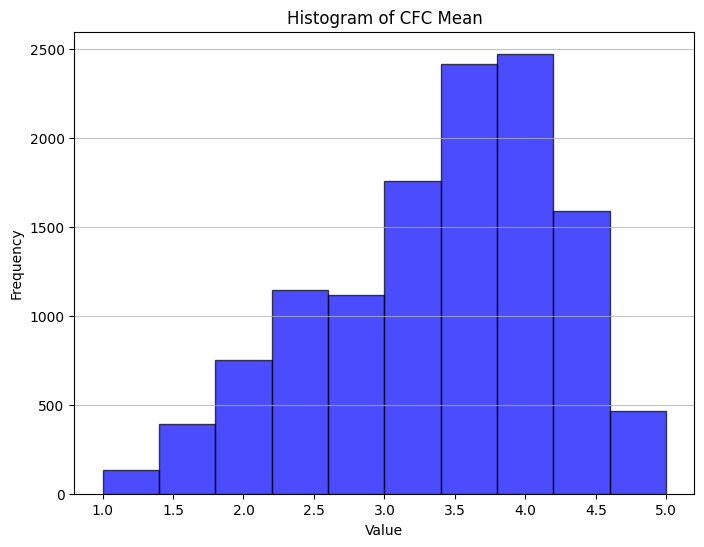

In [7]:
# Plot histogram for means
plt.figure(figsize=(8, 6))
plt.hist(df2['scale_mn'], alpha=0.7, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of CFC Mean')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.grid(axis='y', alpha=0.75)
plt.show()



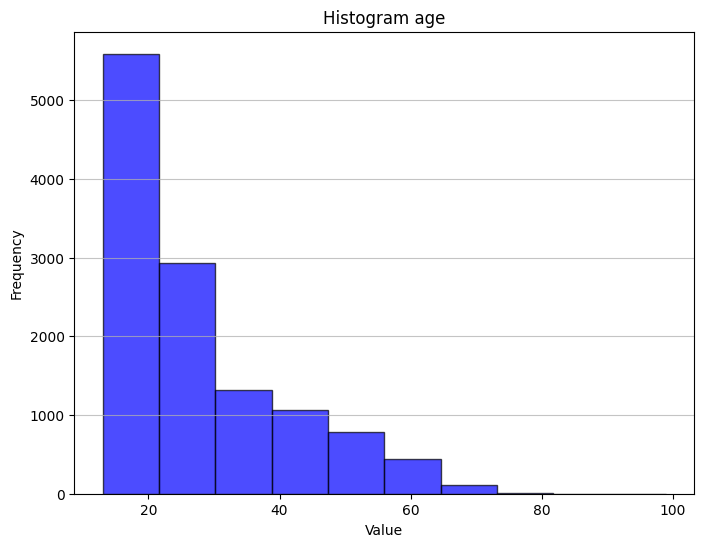

In [8]:
# Visualize age

plt.figure(figsize=(8, 6))
plt.hist(df2['age'], alpha=0.7, color='blue', edgecolor='black')


# Add titles and labels
plt.title('Histogram age')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.grid(axis='y', alpha=0.75)
plt.show()



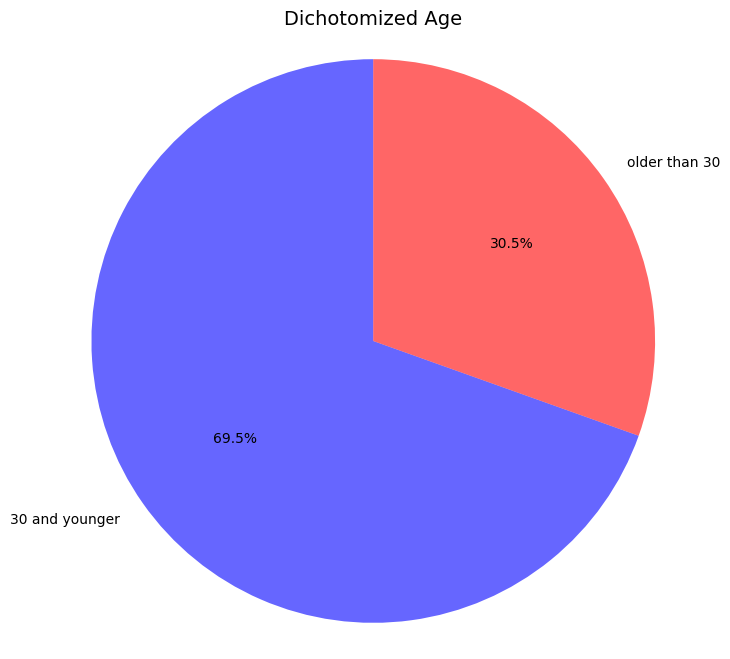

In [9]:
# FEATURE: Create dichotomized age
df2= df2.copy()
df2['age.grp']  = df2['age'].apply(lambda x: '30 and younger' if x <= 30 else 'older than 30')

# Count the occurrences of each gender
age_counts = df2['age.grp'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90,  colors=['blue', 'red', "grey"], wedgeprops={"alpha": 0.6})
plt.title('Dichotomized Age', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

# Show the plot
plt.show()

#FEATURE: Create 5-year age category
df2['age_category'] = df2['age'] // 5

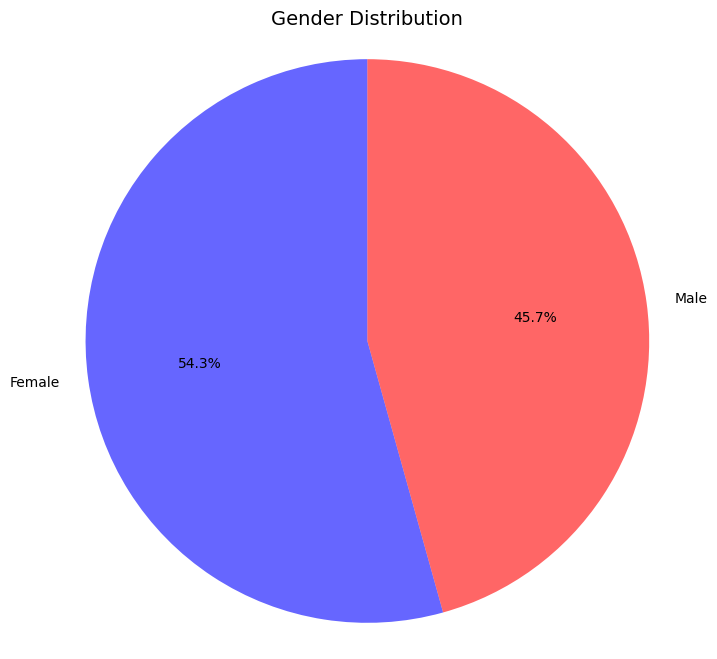

In [10]:
# Replace numeric values with corresponding labels
df2=  df2.copy()
df2['gender'] = df2['gender'].replace({1: 'Male', 2: 'Female', 3: 'Other'})


# Count the occurrences of each gender
gender_counts = df2['gender'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90,  colors=['blue', 'red', "grey"], wedgeprops={"alpha": 0.6})
plt.title('Gender Distribution', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

# Show the plot
plt.show()

In [11]:
from scipy.stats import pearsonr,t

# t-test to confirm
group1 = df2[df2['gender'] == 'Male']['scale_mn']
group2 = df2[df2['gender'] == 'Female']['scale_mn']

t_stat, p_value = stats.ttest_ind(group1, group2)

# Calculate means and confidence intervals
def compute_ci(data, confidence=0.95):
    mean = data.mean()
    sem = stats.sem(data)  # Standard Error of the Mean
    margin_of_error = sem * stats.t.ppf((1 + confidence) / 2., len(data) - 1)
    return mean, mean - margin_of_error, mean + margin_of_error

mean1, ci_lower1, ci_upper1 = compute_ci(group1)
mean2, ci_lower2, ci_upper2 = compute_ci(group2)

# Display results - sig difference between ages (but overpowered study)
print(f'T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}')
print(f'Group 1 (Male): Mean = {mean1:.2f}, 95% CI = [{ci_lower1:.2f}, {ci_upper1:.2f}]')
print(f'Group 2 (Female): Mean = {mean2:.2f}, 95% CI = [{ci_lower2:.2f}, {ci_upper2:.2f}]')
print(len(df))

T-statistic: 2.2892, P-value: 0.0221
Group 1 (Male): Mean = 3.41, 95% CI = [3.39, 3.43]
Group 2 (Female): Mean = 3.38, 95% CI = [3.36, 3.40]
14814


Correlation: 0.09968554724114259
P-value: 2.0714734451619193e-28
95% Confidence Interval: (0.0820549432389263, 0.11731615124335888)


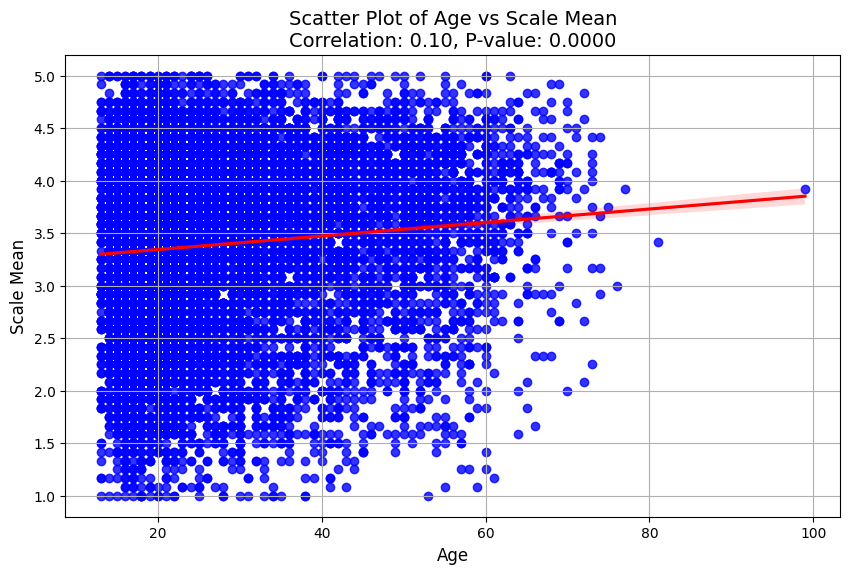

In [12]:


#INFERENTIAL: Do people consider more future consequences when older? correlation
df = df2.copy()

# Calculate correlation and p-value
corr, p_value = pearsonr(df['age'], df['scale_mn'])

# Calculate confidence interval
n = len(df['gender'])  # number of samples
alpha = 0.05  # significance level
t_score = t.ppf(1 - alpha/2, df=n-2)  # t critical value for two-tailed test

# Calculate the standard error of the correlation
se = np.sqrt((1 - corr**2) / (n - 2))

# Confidence interval calculation
ci_lower = corr - t_score * se
ci_upper = corr + t_score * se

# Output results
print("Correlation:", corr)
print("P-value:", p_value)
print("95% Confidence Interval:", (ci_lower, ci_upper))

# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='age', y='scale_mn', data=df, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})

# Add titles and labels
plt.title(f'Scatter Plot of Age vs Scale Mean\nCorrelation: {corr:.2f}, P-value: {p_value:.4f}', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Scale Mean', fontsize=12)

# Show the plot
plt.grid()
plt.show()

# CONCLUSION: There appears to be a significant positive correlation of age and CFC score-- older people consider behaviour that has distal consequences
# BUT with large enough N, anything is significant, is 0.1 correlation meaningful?

In [13]:
# t-test to confirm
group1 = df[df['age.grp'] == '30 and younger']['scale_mn']
group2 = df[df['age.grp'] == 'older than 30']['scale_mn']

t_stat, p_value = stats.ttest_ind(group1, group2)

# Calculate means and confidence intervals
def compute_ci(data, confidence=0.95):
    mean = data.mean()
    sem = stats.sem(data)  # Standard Error of the Mean
    margin_of_error = sem * stats.t.ppf((1 + confidence) / 2., len(data) - 1)
    return mean, mean - margin_of_error, mean + margin_of_error

mean1, ci_lower1, ci_upper1 = compute_ci(group1)
mean2, ci_lower2, ci_upper2 = compute_ci(group2)

# Display results - sig difference between ages (but overpowered study)
print(f'T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}')
print(f'Group 1 (30 and younger): Mean = {mean1:.2f}, 95% CI = [{ci_lower1:.2f}, {ci_upper1:.2f}]')
print(f'Group 2 (older than 30): Mean = {mean2:.2f}, 95% CI = [{ci_lower2:.2f}, {ci_upper2:.2f}]')

T-statistic: -9.1501, P-value: 0.0000
Group 1 (30 and younger): Mean = 3.35, 95% CI = [3.33, 3.37]
Group 2 (older than 30): Mean = 3.50, 95% CI = [3.47, 3.52]


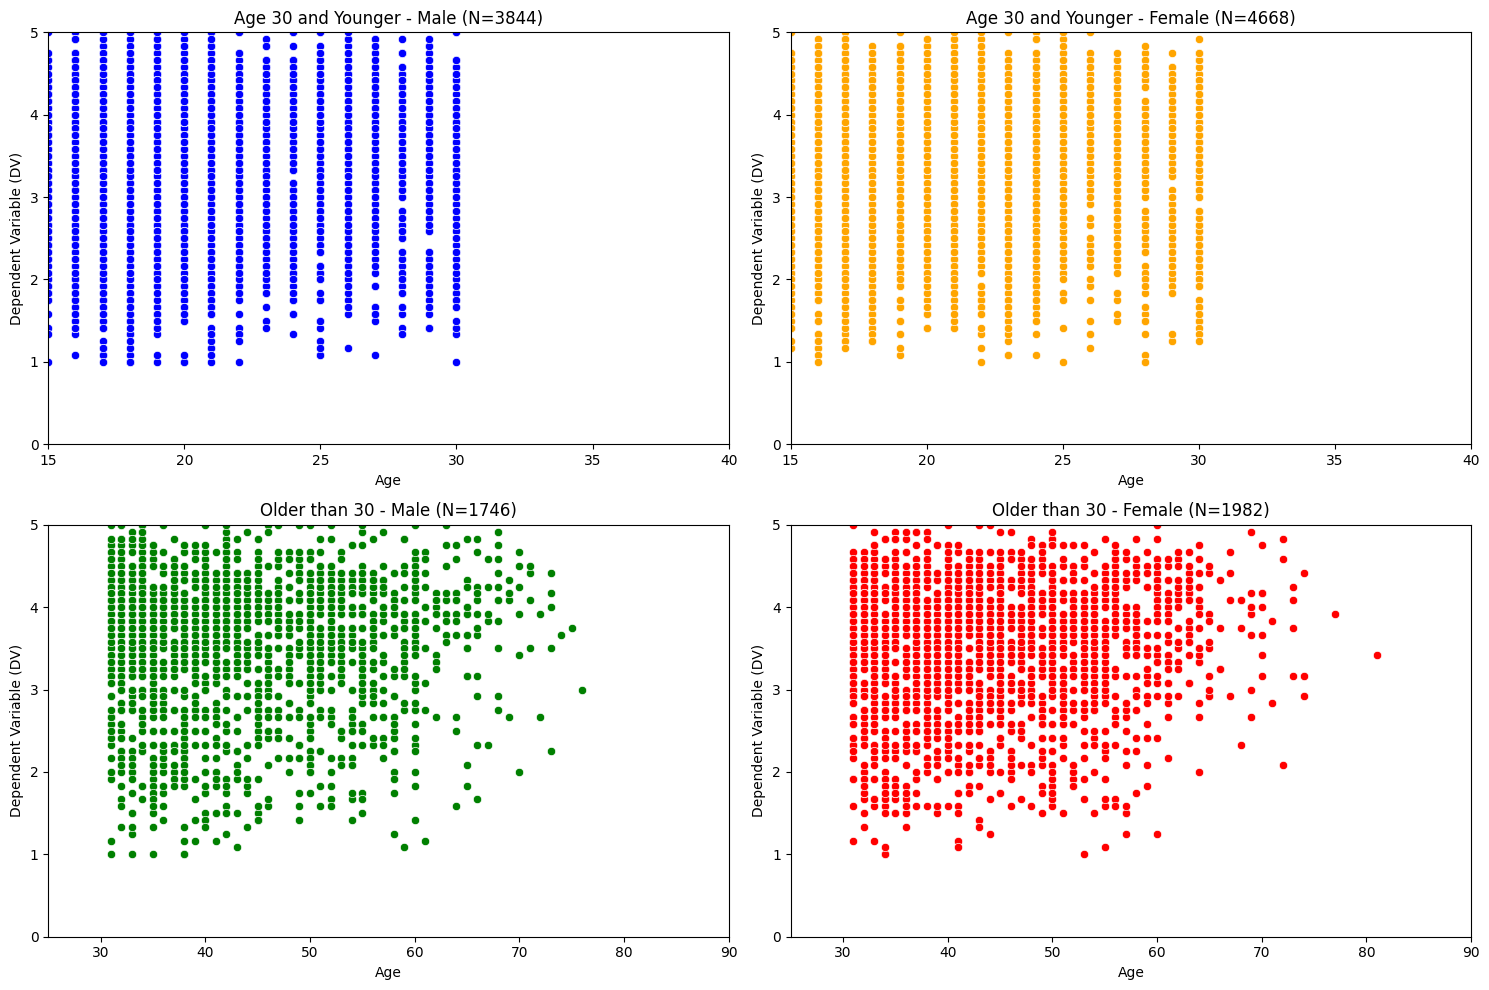

In [14]:
#Some intuitive analysis, split by gender and dichotomized age
#Visualize scale mean across 4 categories (age crossed with gender)

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Create scatter plot for '30 and younger' - Male
count_30M = len(df[(df['age.grp'] == '30 and younger')&(df['gender'] == 'Male')])
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, 1st subplot
sns.scatterplot(x='age', y='scale_mn', data=df[(df['age.grp'] == '30 and younger') & (df['gender'] == 'Male')], color='blue')
plt.title(f'Age 30 and Younger - Male (N={count_30M})')
plt.xlabel('Age')
plt.ylabel('Dependent Variable (DV)')
plt.xlim(15, 40)  # Adjust as needed
plt.ylim(0, 5)    # Adjust as needed

# Create scatter plot for '30 and younger' - Female
count_30F = len(df[(df['age.grp'] == '30 and younger')&(df['gender'] == 'Female')])
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, 2nd subplot
sns.scatterplot(x='age', y='scale_mn', data=df[(df['age.grp'] == '30 and younger') & (df['gender'] == 'Female')], color='orange')
plt.title(f'Age 30 and Younger - Female (N={count_30F})')
plt.xlabel('Age')
plt.ylabel('Dependent Variable (DV)')
plt.xlim(15, 40)  # Adjust as needed
plt.ylim(0, 5)    # Adjust as needed

# Create scatter plot for 'older than 30' - Male
count_M30 = len(df[(df['age.grp'] == 'older than 30')&(df['gender'] == 'Male')])
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, 3rd subplot
sns.scatterplot(x='age', y='scale_mn', data=df[(df['age.grp'] == 'older than 30') & (df['gender'] == 'Male')], color='green')
plt.title(f'Older than 30 - Male (N={count_M30})')
plt.xlabel('Age')
plt.ylabel('Dependent Variable (DV)')
plt.xlim(25, 90)  # Adjust as needed
plt.ylim(0, 5)    # Adjust as needed

# Create scatter plot for 'older than 30' - Female
count_F30 = len(df[(df['age.grp'] == 'older than 30')&(df['gender'] == 'Female')])
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, 4th subplot
sns.scatterplot(x='age', y='scale_mn', data=df[(df['age.grp'] == 'older than 30') & (df['gender'] == 'Female')], color='red')
plt.title(f'Older than 30 - Female (N={count_F30})')
plt.xlabel('Age')
plt.ylabel('Dependent Variable (DV)')
plt.xlim(25, 90)  # Adjust as needed
plt.ylim(0, 5)    # Adjust as needed

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [15]:
from statsmodels.formula.api import ols


model = ols('scale_mn ~ age + C(gender)+age:C(gender)', data=df).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               scale_mn   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     42.61
Date:                Thu, 21 Nov 2024   Prob (F-statistic):           2.20e-27
Time:                        05:18:50   Log-Likelihood:                -15071.
No. Observations:               12240   AIC:                         3.015e+04
Df Residuals:                   12236   BIC:                         3.018e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.21

In [16]:
from statsmodels.formula.api import ols


model = ols('scale_mn ~ age + C(gender)', data=df).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               scale_mn   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     63.35
Date:                Thu, 21 Nov 2024   Prob (F-statistic):           4.28e-28
Time:                        05:18:50   Log-Likelihood:                -15071.
No. Observations:               12240   AIC:                         3.015e+04
Df Residuals:                   12237   BIC:                         3.017e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.2038      0.01

In [17]:
#FEATURE: Create variable for people who directionally scored the same through the whole scale (as an extreme responder)

# List of column names for the 12 scale items
allcols_eqcode = ['Q1', 'Q2', 'Q6', 'Q7', 'Q8', 'Q3_R', 'Q4_R', 'Q5_R', 'Q9_R', 'Q10_R', 'Q11_R', 'Q12_R']

# Sum the extreme low responses (1s) across the specified items for each participant
df['extreme_low_count'] = (df[allcols_eqcode] == 1).sum(axis=1)

# Sum the extreme low responses (1s) across the specified items for each participant
df['extreme_high_count'] = (df[allcols_eqcode] == 5).sum(axis=1)



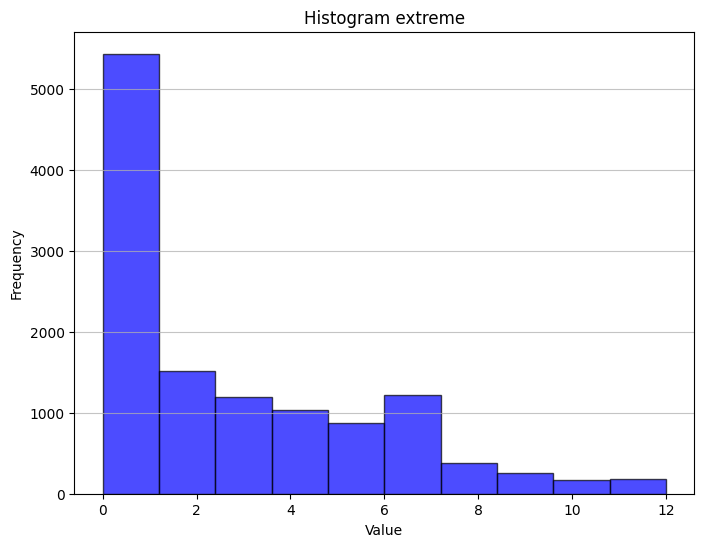

age.grp
30 and younger    8305
older than 30     3583
Name: count, dtype: int64

In [18]:

# Visualize high responders

plt.figure(figsize=(8, 6))
plt.hist(df['extreme_high_count'], alpha=0.7, color='blue', edgecolor='black')


# Add titles and labels
plt.title('Histogram extreme')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.grid(axis='y', alpha=0.75)
plt.show()

#how do they differ by age group at the higher end? 
df[df['extreme_high_count']<=9]['age.grp'].value_counts()


In [19]:
import statsmodels.api as sm
# Step 1: Define Target Variable
def categorize_age_gender(row):
    if row['gender'] == 'Male' and row['age'] < 30:
        return 0  # Male under 30
    elif row['gender'] == 'Male' and row['age'] >= 30:
        return 1  # Male over 30
    elif row['gender'] == 'Female' and row['age'] < 30:
        return 2  # Female under 30
    elif row['gender'] == 'Female' and row['age'] >= 30:
        return 3  # Female over 30
    else:
        return 99

df['age_gender_category'] = df.apply(categorize_age_gender, axis=1)
# Define the target variable
y = df['age_gender_category']  # This is your dependent variable

# Define the predictor variables (you can include the interaction terms directly here)
X = df[allcols_eqcode]  # This includes the predictors

# Create interaction terms using patsy or manually
# Manually adding interaction terms for Q2 * Q5_R, Q2 * Q12_R, Q5_R * Q12_R, and Q2 * Q5_R * Q12_R
X['Q2_Q5_R'] = X['Q2'] * X['Q5_R']
X['Q2_Q12_R'] = X['Q2'] * X['Q12_R']
X['Q5_R_Q12_R'] = X['Q5_R'] * X['Q12_R']
X['Q2_Q5_R_Q12_R'] = X['Q2'] * X['Q5_R'] * X['Q12_R']

# Add an intercept term to the model
X = sm.add_constant(X)

# Fit the multinomial logistic regression model
model = sm.MNLogit(y, X)
result = model.fit()

# Print the summary of the model
print(result.summary())


/tmp/ipykernel_17/1212298901.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Q2_Q5_R'] = X['Q2'] * X['Q5_R']
/tmp/ipykernel_17/1212298901.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Q2_Q12_R'] = X['Q2'] * X['Q12_R']
/tmp/ipykernel_17/1212298901.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Optimization terminated successfully.
         Current function value: 1.291085
         Iterations 5
                           MNLogit Regression Results                          
Dep. Variable:     age_gender_category   No. Observations:                12240
Model:                         MNLogit   Df Residuals:                    12189
Method:                            MLE   Df Model:                           48
Date:                 Thu, 21 Nov 2024   Pseudo R-squ.:                 0.02191
Time:                         05:18:53   Log-Likelihood:                -15803.
converged:                        True   LL-Null:                       -16157.
Covariance Type:             nonrobust   LLR p-value:                3.196e-118
age_gender_category=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.5105      0.372     -1.372      0.170      -1.240 

# SECTION 3: Applying some ML algorithms

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


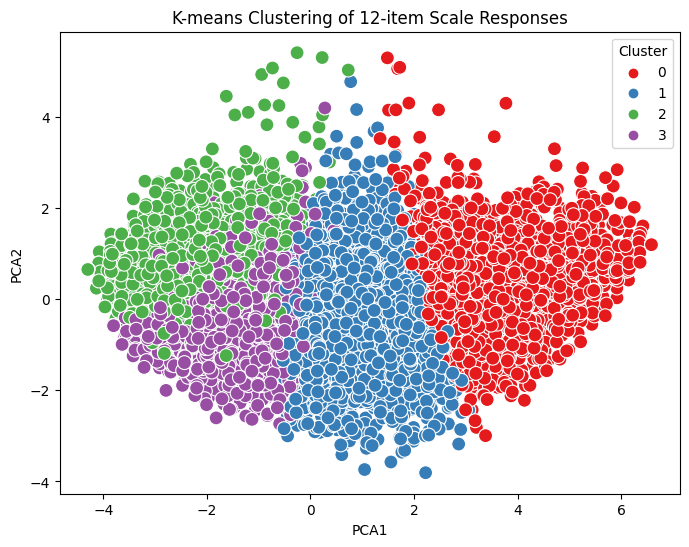

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#how do people cluster based on their scale answers?

kmdf=df.copy()
kmdf=kmdf[allcols_eqcode]
# Step 1: Normalize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(kmdf)

# Step 2: Apply K-means clustering
k = 4  # You can experiment with different values of k
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Step 3: Dimensionality Reduction for Visualization (optional)
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
pca_components = pca.fit_transform(df_scaled)
df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# Step 4: Plot the clusters in 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', s=100)
plt.title('K-means Clustering of 12-item Scale Responses')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

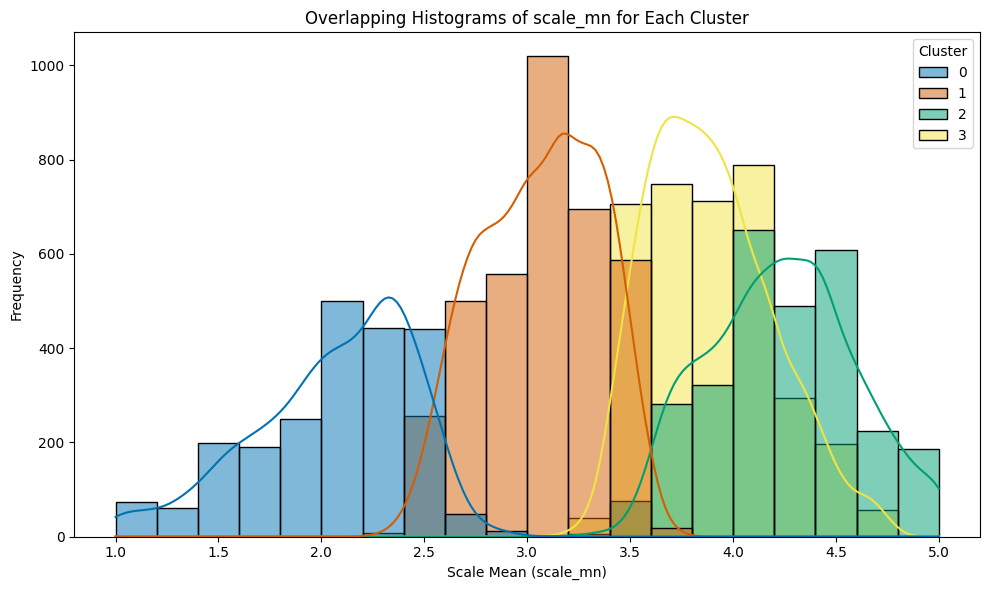

In [21]:
#Visualize their scale mean scores as overlapping histograms, based on clustering of their individual items
dfx = df.copy()

# Set up the figure for the histogram
plt.figure(figsize=(10, 6))


colors = ['#0072B2', '#D55E00', '#009E73', '#F0E442']

# colors = ['#0072B2', '#D55E00', '#009E73', '#F0E442', '#CC79A7', '#444444']


# colors = [
#     '#0072B2', '#D55E00', '#009E73', '#F0E442', '#CC79A7', '#444444',
#     '#56B4E9', '#E69F00', '#009E73', '#F4A582', '#F7D0CB', '#5F4C42'
# ]


# Plot overlapping histograms for each cluster with different colors
sns.histplot(dfx, x="scale_mn", hue="Cluster", multiple="layer", palette=colors, bins=20, kde=True)

# Add titles and labels
plt.title('Overlapping Histograms of scale_mn for Each Cluster')
plt.xlabel('Scale Mean (scale_mn)')
plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()

In [22]:
dfx[dfx['Cluster']==2]['age.grp'].value_counts()

age.grp
30 and younger    1688
older than 30     1156
Name: count, dtype: int64

Looks like a lot of overlap, meaning the CFC scale is hard to distinguish different groups. Though the Cluster 2 and Cluster 0 are interesting as they score in a very discernable way from one another.

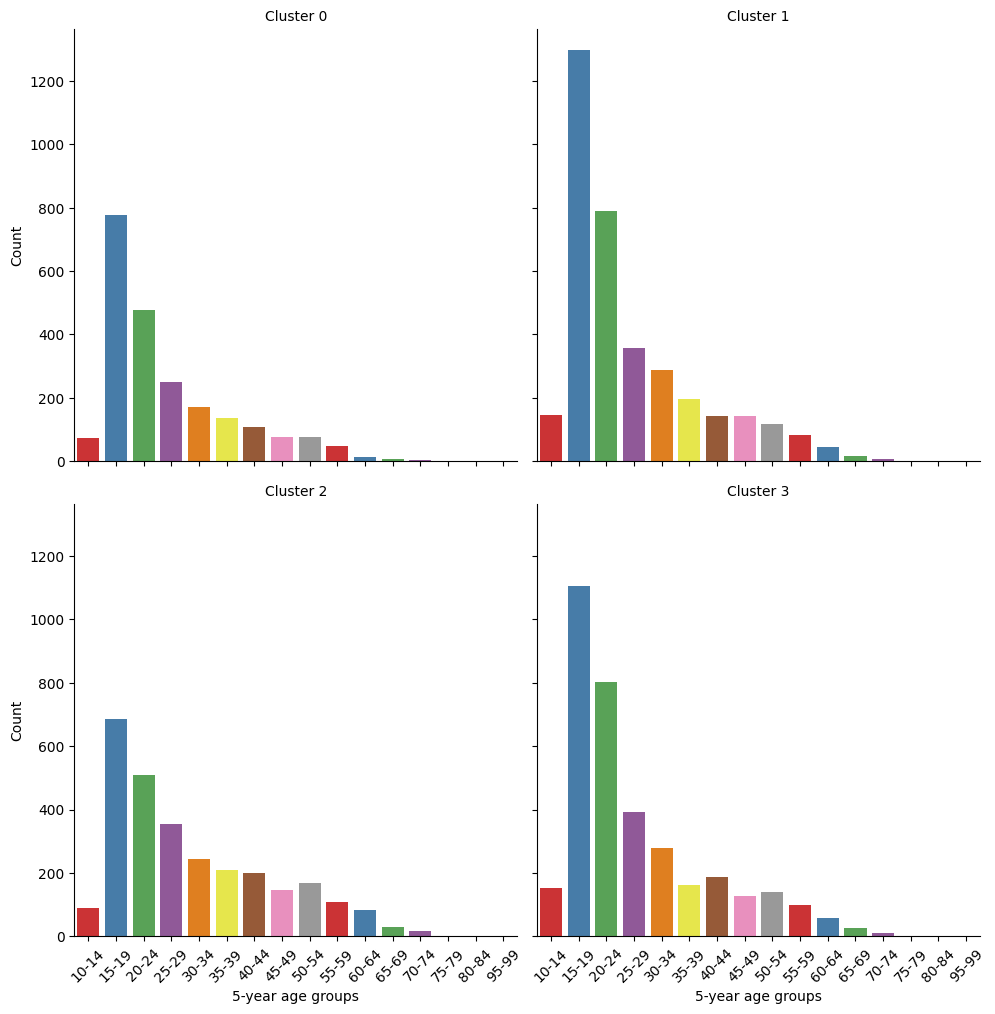

In [23]:
# Define age range labels for 5-year age groups
age_labels = ["10-14", "15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49", 
              "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80-84", "95-99"]

# Map numerical categories in 'age_category' to these labels if necessary
# Example: dfx['age_category'] = dfx['age_category'].replace(dict(enumerate(age_labels)))

# Set up the FacetGrid to create separate plots for each cluster
g = sns.FacetGrid(dfx, col='Cluster', col_wrap=2, height=5, palette="Set1")

# Create the count plot for the 4-category variable within each cluster
g.map(sns.countplot, 'age_category', order=sorted(dfx['age_category'].unique()),  palette="Set1")


# Add titles and labels
g.set_axis_labels('5-year age groups', 'Count')
g.set_titles('Cluster {col_name}')

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    ax.set_xticklabels(age_labels, rotation=45)

# Show the plot

plt.show()


# MACHINE LEARNING PRACTICE
## ML code adapted from stock exercises on kaggle and generated from chatGPT prompts
## Can ANN use scale items to predict age/gender better than chance?

In [24]:
#try ANN
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.layers import Dropout

# Define features and target
X = df[allcols_eqcode]  # Assuming CFC_score is your feature
y = df['age_gender_category']  # Assuming this is already encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)

# Build the neural network model with Dropout
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))  # Dropout layer with 50% dropout rate
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))  # Another dropout layer
model.add(Dense(4, activation='softmax'))  # Output layer for 4 classes

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model
accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy[1]}")

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3100 - loss: 1.4531 - val_accuracy: 0.3454 - val_loss: 1.3085
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3476 - loss: 1.3458 - val_accuracy: 0.3588 - val_loss: 1.3068
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3551 - loss: 1.3230 - val_accuracy: 0.3606 - val_loss: 1.3027
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3675 - loss: 1.3207 - val_accuracy: 0.3600 - val_loss: 1.3022
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3624 - loss: 1.3158 - val_accuracy: 0.3600 - val_loss: 1.2990
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3726 - loss: 1.3177 - val_accuracy: 0.3600 - val_loss: 1.2994
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3778 - loss: 1.3006 - val_accuracy: 0.3606 - val_loss: 1.2953
Epoch 8/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3759 - loss: 1.3013 - val_accuracy: 0.

In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import classification_report, mean_squared_error

data = df.copy()

# Prepare features and targets
X = data[allcols_eqcode]
y_age = data['age']
y_gender = (data['gender'] == 'Male').astype(int)  # Convert to binary (Male=1, Female=0)

# Split data into training and testing
X_train, X_test, y_age_train, y_age_test = train_test_split(X, y_age, test_size=0.2, random_state=42)
_, _, y_gender_train, y_gender_test = train_test_split(X, y_gender, test_size=0.2, random_state=42)

# Regression (Age)
regressor = RandomForestRegressor(random_state=42)
regressor.fit(X_train, y_age_train)
y_age_pred = regressor.predict(X_test)

print("Regression Results (Age):")
print(f"RMSE: {mean_squared_error(y_age_test, y_age_pred, squared=False):.2f}")

# Classification (Gender)
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_gender_train)
y_gender_pred = classifier.predict(X_test)

print("\nClassification Results (Gender):")
print(classification_report(y_gender_test, y_gender_pred, target_names=['Female', 'Male']))

# Cross-Validation Example
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(classifier, X, y_gender, cv=kf, scoring='accuracy')

print("\nCross-Validation Accuracy (Gender):")
print(f"Mean Accuracy: {np.mean(cv_scores):.2f}, Std Dev: {np.std(cv_scores):.2f}")

# Combined Prediction (Age + Gender)
from sklearn.multioutput import MultiOutputRegressor

multi_target_model = MultiOutputRegressor(RandomForestRegressor(random_state=42))
multi_target_model.fit(X_train, np.column_stack((y_age_train, y_gender_train)))

y_combined_pred = multi_target_model.predict(X_test)
y_age_combined_pred, y_gender_combined_pred = y_combined_pred[:, 0], (y_combined_pred[:, 1] > 0.5).astype(int)

print("\nCombined Prediction Results:")
print(f"RMSE (Age): {mean_squared_error(y_age_test, y_age_combined_pred, squared=False):.2f}")
print("Classification Report (Gender):")
print(classification_report(y_gender_test, y_gender_combined_pred, target_names=['Female', 'Male']))


Regression Results (Age):
RMSE: 13.43

Classification Results (Gender):
              precision    recall  f1-score   support

      Female       0.56      0.65      0.60      1340
        Male       0.47      0.38      0.42      1108

    accuracy                           0.53      2448
   macro avg       0.52      0.52      0.51      2448
weighted avg       0.52      0.53      0.52      2448


Cross-Validation Accuracy (Gender):
Mean Accuracy: 0.53, Std Dev: 0.01

Combined Prediction Results:
RMSE (Age): 13.43
Classification Report (Gender):
              precision    recall  f1-score   support

      Female       0.55      0.63      0.59      1340
        Male       0.46      0.39      0.42      1108

    accuracy                           0.52      2448
   macro avg       0.51      0.51      0.50      2448
weighted avg       0.51      0.52      0.51      2448



In [26]:
print(f"Range: {df['age'].min()} - {df['age'].max()}")

Range: 13 - 99
